In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [2]:
def fill_with_edge_color(image_path, fill_percent=0.5, fill_direction='left',rotate=True):
    # Load the image
    img = cv2.imread(image_path,cv2.IMREAD_UNCHANGED)
    if rotate:
        img =  cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    img = img[:, :, 0:3]
    if img is None:
        raise ValueError("Image not found or invalid format.")
    
    height, width = img.shape[:2]
    fill_percent = max(0.0, min(1.0, fill_percent))  # clamp 0–1

    if fill_direction == 'left':
        fill_width = int(width * fill_percent)
        source_col = min(fill_width, width - 1)
        column = img[:, source_col:source_col + 1]
        for col in range(fill_width):
            img[:, col:col + 1] = column

    elif fill_direction == 'right':
        fill_width = int(width * fill_percent)
        source_col = max(width - fill_width - 1, 0)
        column = img[:, source_col:source_col + 1]
        for col in range(width - fill_width, width):
            img[:, col:col + 1] = column

    elif fill_direction == 'up':
        fill_height = int(height * fill_percent)
        source_row = min(fill_height, height - 1)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(fill_height):
            img[row_idx:row_idx + 1, :] = row

    elif fill_direction == 'down':
        fill_height = int(height * fill_percent)
        source_row = max(height - fill_height - 1, 0)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(height - fill_height, height):
            img[row_idx:row_idx + 1, :] = row

    else:
        raise ValueError("fill_direction must be one of: 'left', 'right', 'up', 'down'.")


    return img

In [5]:
out_folder = "imgs_plants_mod"
out_folder = "C:\\Users\\Elirio\\Desktop\\images_results\\butterfly_fill2\\"
if not os.path.isdir(out_folder):
    os.mkdir(out_folder)

C:\Users\Elirio\Desktop\images_results\original\IMG_4492.JPG


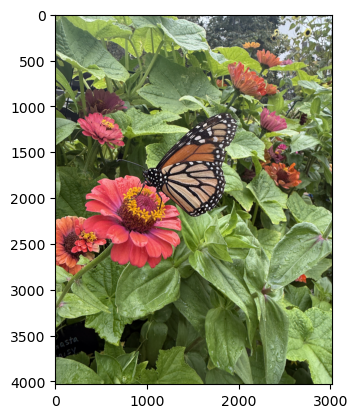

In [7]:
#imgs_folder = "imgs_plants"
imgs_folders = "C:\\Users\\Elirio\\Desktop\\images_results\\original"
f = "IMG_4492.JPG"
ii = os.path.join(imgs_folders,f)
print(ii)
imgg = cv2.imread(ii)
img_rgb = cv2.cvtColor(imgg,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [17]:
listf = []
for direction in ['right', 'up', 'down', 'left']:
    temp_list  = []
    for i in range(101):
       filled = fill_with_edge_color(ii, fill_percent=1 - i/100, fill_direction=direction,rotate=True)
        outimg = os.path.join(out_folder,f"{direction}_{100 - i }.png" )
        temp_list.append(outimg)
        cv2.imwrite(outimg, filled)
        if i % 100 == 0:
            listf +=temp_list
            listf += temp_list[::-1]          
        
    

In [19]:
listfile = "list3.txt"
with open(listfile,"w") as file:
    for o in listf:
        file.write(f"file '{o}'\nduration 0.005\n" )
    

In [23]:
!ffmpeg -f concat -safe 0 -i list3.txt -c:v libx264 -pix_fmt yuv420p -c:a aac output3.mp4

ffmpeg version N-120454-g16d663d371-20250803 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.1.0 (crosstool-NG 1.27.0.42_35c1e72)
  configuration: --prefix=/ffbuild/prefix --pkg-config-flags=--static --pkg-config=pkg-config --cross-prefix=x86_64-w64-mingw32- --arch=x86_64 --target-os=mingw32 --enable-gpl --enable-version3 --disable-debug --enable-shared --disable-static --disable-w32threads --enable-pthreads --enable-iconv --enable-zlib --enable-libfribidi --enable-gmp --enable-libxml2 --enable-lzma --enable-fontconfig --enable-libharfbuzz --enable-libfreetype --enable-libvorbis --enable-opencl --disable-libpulse --enable-libvmaf --disable-libxcb --disable-xlib --enable-amf --enable-libaom --enable-libaribb24 --enable-avisynth --enable-chromaprint --enable-libdav1d --enable-libdavs2 --enable-libdvdread --enable-libdvdnav --disable-libfdk-aac --enable-ffnvcodec --enable-cuda-llvm --enable-frei0r --enable-libgme --enable-libkvazaar --enable-libaribcaption --enable-libas